In [1]:
import numpy as np
import torch

import matplotlib.pyplot as plt
import matplotlib as mpl

import os

from tqdm import tqdm

from rctorch.models import MorrisLecar, MorrisLecarCurrent
from rctorch.reservoir import Reservoir
from rctorch.supervisors import LorenzAttractor
from rctorch.utils import minmax_transform

In [196]:
T = 10_000 # ms
dt = 0.1 # ms

t = np.arange(0, T, dt)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

x = LorenzAttractor(T=T, dt=dt, tau=0.02).generate(transient_time=500)

x = minmax_transform(x.T, zero_mean=True)

tau = 0.02
x = np.sin(2 * np.pi * 0.01 * t * tau).reshape(-1, 1)
sup = torch.from_numpy(x).float().to(device)

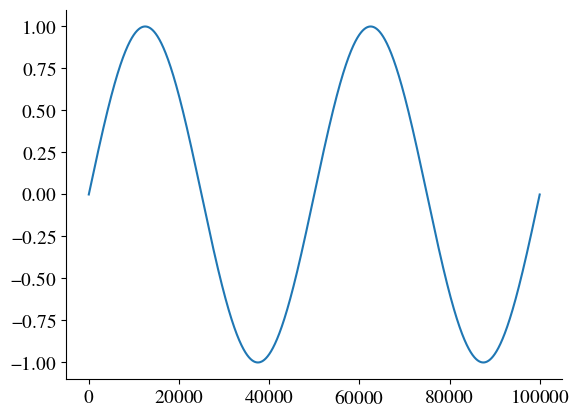

In [197]:
plt.plot(sup[:, 0].cpu().numpy())

In [198]:
Ne = 400
Ni = 100
N = Ne + Ni

current = torch.ones((N, 1), device=device) * 70

model_params = {
    'device': device,
    'Ne': Ne,
    'Ni': Ni,
    'BIAS': current,
    # 'w_in_amp': 400,
    'gbar': 5.0,
    'dt': dt,
    'p_sparsity': 0.01,
}

In [199]:
ml = MorrisLecarCurrent(**model_params)

W_in = torch.rand(ml.N, sup.shape[1], device=device) * 2 - 1
W_in *= 500

ml_copy = MorrisLecarCurrent(**model_params)
ml_copy.mem = ml.mem.clone()
ml_copy.s = ml.s.clone()
# ml_copy.n = ml.n.clone()
ml_copy.w = ml.w.clone()
W_in.size()

torch.Size([500, 1])

In [200]:
torch.any(ml.n == ml_copy.n)

tensor(False, device='cuda:0')

In [201]:
ml.w.min(), ml.w.max(), ml.w.mean(), ml.w.std()

(tensor(-1.9475, device='cuda:0'),
 tensor(2.1934, device='cuda:0'),
 tensor(0.0001, device='cuda:0'),
 tensor(0.4471, device='cuda:0'))

In [202]:
nt_transient = int(1_000 // dt)

for i in tqdm(range(nt_transient)):
    ml.forward(0.0)
    ml_copy.forward(0.0)

100%|██████████| 9999/9999 [00:06<00:00, 1511.03it/s]


In [203]:
s_rec = torch.zeros((sup.shape[0], ml.N), device='cpu')
s_rec_copy = torch.zeros((sup.shape[0], ml.N), device='cpu')

for i in tqdm(range(sup.shape[0])):
    ml.forward(W_in @ sup[i].reshape(-1, 1))
    ml_copy.forward(W_in @ sup[i].reshape(-1, 1))
    s_rec[i] = ml.s.clone().cpu().flatten()
    s_rec_copy[i] = ml_copy.s.clone().cpu().flatten()


100%|██████████| 100000/100000 [01:12<00:00, 1375.57it/s]


In [204]:
t = np.arange(s_rec.shape[0]) * dt

# find times ml.s crosses over ml._v_t as a spike time
spikes = [[] for _ in range(ml.N)]
spikes_copy = [[] for _ in range(ml.N)]

In [205]:
for n in tqdm(range(ml.N)):
    mask = torch.logical_and(s_rec[:-1, n] < 0.5, s_rec[1:, n] >= 0.5)
    idxs = torch.where(mask)[0]
    for idx in idxs:
        spikes[n].append(t[idx+1])
    mask_copy = torch.logical_and(s_rec_copy[:-1, n] < 0.5, s_rec_copy[1:, n] >= 0.5)
    idxs_copy = torch.where(mask_copy)[0]
    for idx in idxs_copy:
        spikes_copy[n].append(t[idx+1])

100%|██████████| 500/500 [00:00<00:00, 2319.45it/s]


In [206]:
from plot_styles import set_thesis_style

set_thesis_style()

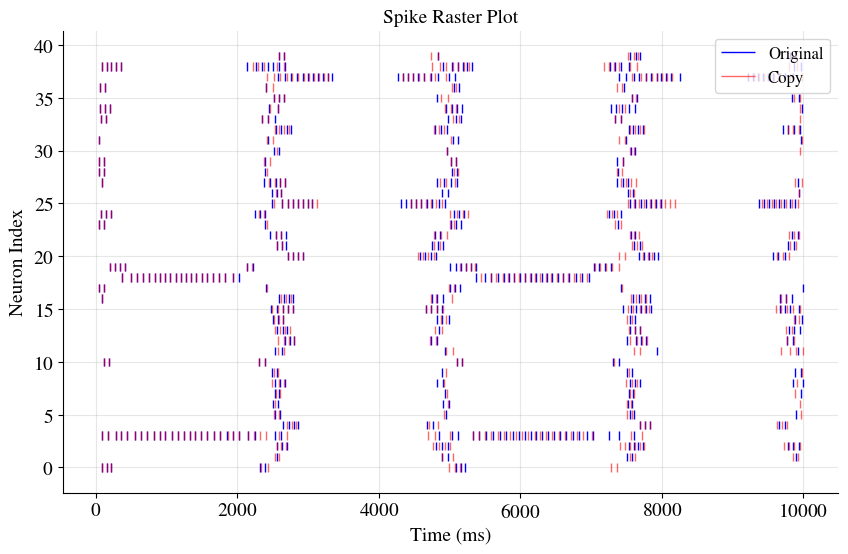

In [207]:
neurons = np.arange(40)

plt.figure(figsize=(10, 6))
for n in neurons:
    orig_line = plt.vlines(spikes[n], n-0.4, n+0.4, lw=1, color='blue', label='Original')
    copy_line = plt.vlines(spikes_copy[n], n-0.4, n+0.4, lw=1, color='red', label='Copy', alpha=0.6)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.title('Spike Raster Plot')
plt.grid(alpha=0.3)
plt.legend([orig_line, copy_line], ['Original', 'Copy'])
plt.show()